In [2]:
import ast
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
import pandas as pd
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_US = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()


In [4]:
df_DA_US['job_Month'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_Skills_Explode = df_DA_US.explode('job_skills')
df_DA_US_Pivot = df_DA_US_Skills_Explode.pivot_table(index='job_Month', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_US_Pivot.loc['Total'] = df_DA_US_Pivot.sum()
df_DA_US_pivot = df_DA_US_Pivot[df_DA_US_Pivot.loc['Total'].sort_values(ascending=False).index].drop('Total')

In [5]:
df_DA_US_Total = df_DA_US.groupby('job_Month').size()

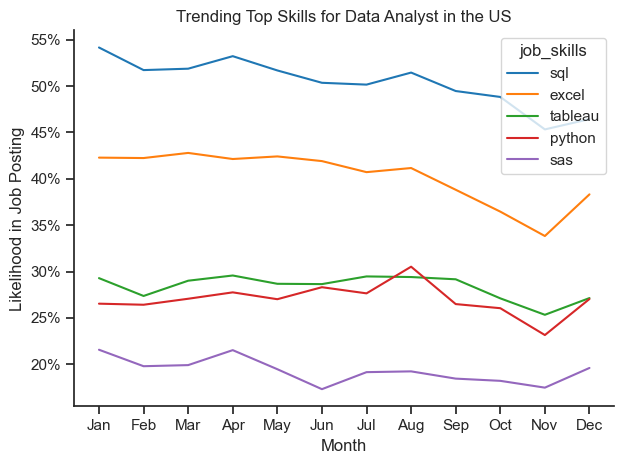

In [12]:
df_DA_US_Percent = df_DA_US_pivot.divide(df_DA_US_Total/100, axis=0)
df_DA_US_Percent = df_DA_US_Percent.reset_index()

#df_DA_US_Percent = df_DA_US_Percent.reset_index()
df_DA_US_Percent['job_Month_Name'] = df_DA_US_Percent['job_Month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_Percent = df_DA_US_Percent.drop('job_Month', axis=1)
df_DA_US_Percent = df_DA_US_Percent.set_index('job_Month_Name')
df_Plot = df_DA_US_Percent.iloc[:, :5]

sns.lineplot(data=df_Plot, dashes=False, palette='tab10')
sns.despine()
sns.set_theme(style='ticks')
plt.title('Trending Top Skills for Data Analyst in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('Month')
from matplotlib.ticker import PercentFormatter
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()